# Processamento Digital de Imagens — Atividade 2
**Capacitação:** Visão Computacional — Residência em TIC43
**Unidade 2 | Capítulo 1 | Tarefa 1**
**Prof.:** Rafael Carmo
**Aluno:** Ednardo Pinheiro Peixoto

**Tema:** Suavização, Remoção de Ruído e Detecção de Bordas, aplicadas ao mini dataset
Copo (Classe A) x Garrafa (Classe B), construído na Atividade 1.

In [1]:
# Clona o repositório com o mini dataset já organizado (Atividade 1)
!git clone https://github.com/EDNARDOPPEIXOTO99/visao-computacional-tic43-copo-garrafa.git
%cd visao-computacional-tic43-copo-garrafa

Cloning into 'visao-computacional-tic43-copo-garrafa'...
remote: Enumerating objects: 17, done.
remote: Total 17 (delta 0), reused 0 (delta 0), pack-reused 17 (from 1)
Receiving objects: 100% (17/17), 44.18 MiB | 28.29 MiB/s, done.
/content/visao-computacional-tic43-copo-garrafa


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## Parte 1 — Seleção das imagens

Critério de seleção: imagens que apresentem granulação, pequenas variações
aleatórias de intensidade, compressão visível ou ruído perceptível.

Para identificar objetivamente as imagens mais adequadas, medimos a nitidez de
cada uma através da variância do Laplaciano (quanto menor o valor, mais a
imagem tende a apresentar suavização indesejada / ruído de baixa frequência /
possível trepidação na captura).

In [3]:
def nitidez(caminho):
    img = cv2.imread(caminho)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

copos = [f"dataset/classe_A_copo/copo{i}.jpg" for i in range(1, 6)]
garrafas = [f"dataset/classe_B_garrafa/garrafa{i}.jpg" for i in range(1, 6)]

print("Classe A - Copo")
for c in copos:
    print(f"  {c}: nitidez (Lap. Var) = {nitidez(c):.1f}")

print("\nClasse B - Garrafa")
for g in garrafas:
    print(f"  {g}: nitidez (Lap. Var) = {nitidez(g):.1f}")

Classe A - Copo
  dataset/classe_A_copo/copo1.jpg: nitidez (Lap. Var) = 69.5
  dataset/classe_A_copo/copo2.jpg: nitidez (Lap. Var) = 71.7
  dataset/classe_A_copo/copo3.jpg: nitidez (Lap. Var) = 163.1
  dataset/classe_A_copo/copo4.jpg: nitidez (Lap. Var) = 92.8
  dataset/classe_A_copo/copo5.jpg: nitidez (Lap. Var) = 94.9

Classe B - Garrafa
  dataset/classe_B_garrafa/garrafa1.jpg: nitidez (Lap. Var) = 119.3
  dataset/classe_B_garrafa/garrafa2.jpg: nitidez (Lap. Var) = 116.0
  dataset/classe_B_garrafa/garrafa3.jpg: nitidez (Lap. Var) = 251.3
  dataset/classe_B_garrafa/garrafa4.jpg: nitidez (Lap. Var) = 106.1
  dataset/classe_B_garrafa/garrafa5.jpg: nitidez (Lap. Var) = 112.4


**Imagens selecionadas** (as duas de menor nitidez de cada classe, indicando
maior presença de degradação/suavização natural da captura):

| Imagem | Classe | Degradação observada | Hipótese sobre a origem |
|---|---|---|---|
| `copo1.jpg` | A - Copo | Leve perda de nitidez nos contornos e no texto da caneca | Captura próxima ao vidro da janela, com reflexo e leve trepidação da mão ao segurar o celular |
| `copo2.jpg` | A - Copo | Textura granulada sutil no fundo (parede/mármore) | Compressão JPEG do celular em ambiente com luz mista (interna + reflexo externo) |
| `garrafa2.jpg` | B - Garrafa | Pequenas variações de intensidade na superfície fosca da garrafa | Reflexo de luz natural pela janela + compressão JPEG suavizando o gradiente da superfície metálica |
| `garrafa4.jpg` | B - Garrafa | Leve desfoque nas bordas do objeto | Foto tirada de mão livre, mais perto do objeto, sem apoio, favorecendo trepidação |


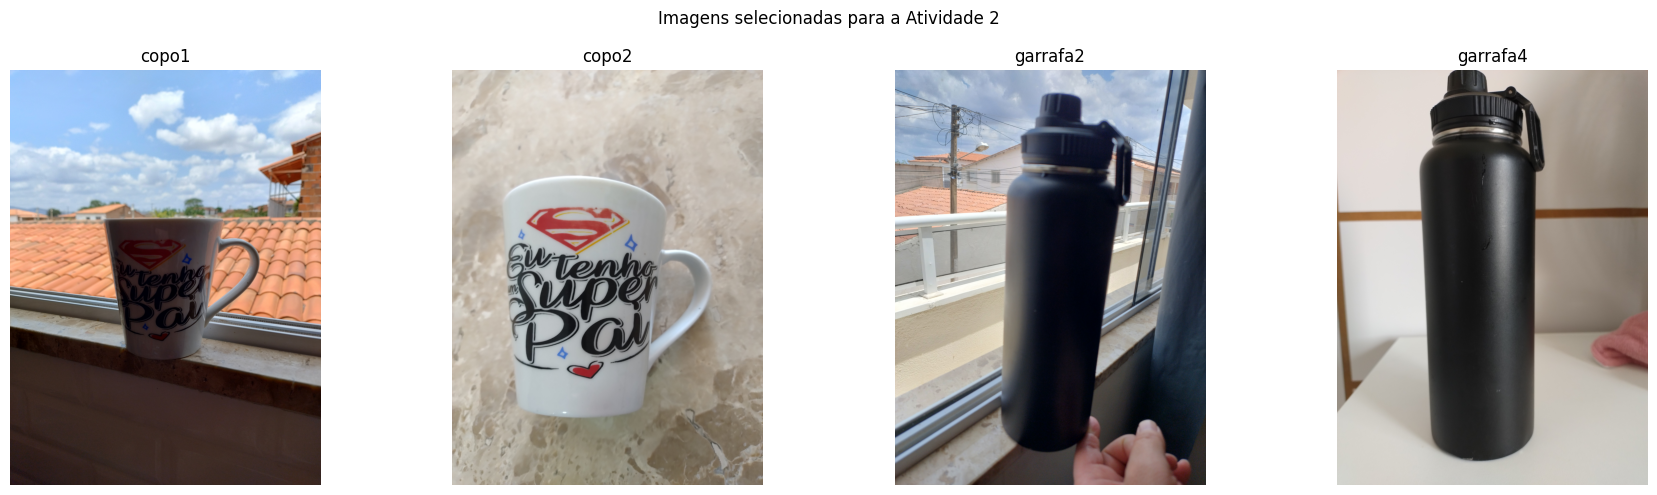

In [4]:
selecionadas = {
    "copo1": "dataset/classe_A_copo/copo1.jpg",
    "copo2": "dataset/classe_A_copo/copo2.jpg",
    "garrafa2": "dataset/classe_B_garrafa/garrafa2.jpg",
    "garrafa4": "dataset/classe_B_garrafa/garrafa4.jpg",
}

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for i, (nome, caminho) in enumerate(selecionadas.items()):
    img = cv2.cvtColor(cv2.imread(caminho), cv2.COLOR_BGR2RGB)
    ax[i].imshow(img)
    ax[i].set_title(nome)
    ax[i].axis('off')
plt.suptitle("Imagens selecionadas para a Atividade 2")
plt.tight_layout()
plt.show()
plt.close(fig)

## Parte 2 — Aplicação de filtros de suavização

Para cada imagem selecionada, aplicamos:
- **Filtro da Média:** kernel 3×3 e 5×5
- **Filtro Gaussiano:** σ = 1 e σ = 3
- **Filtro da Mediana:** kernel 3×3 e 5×5

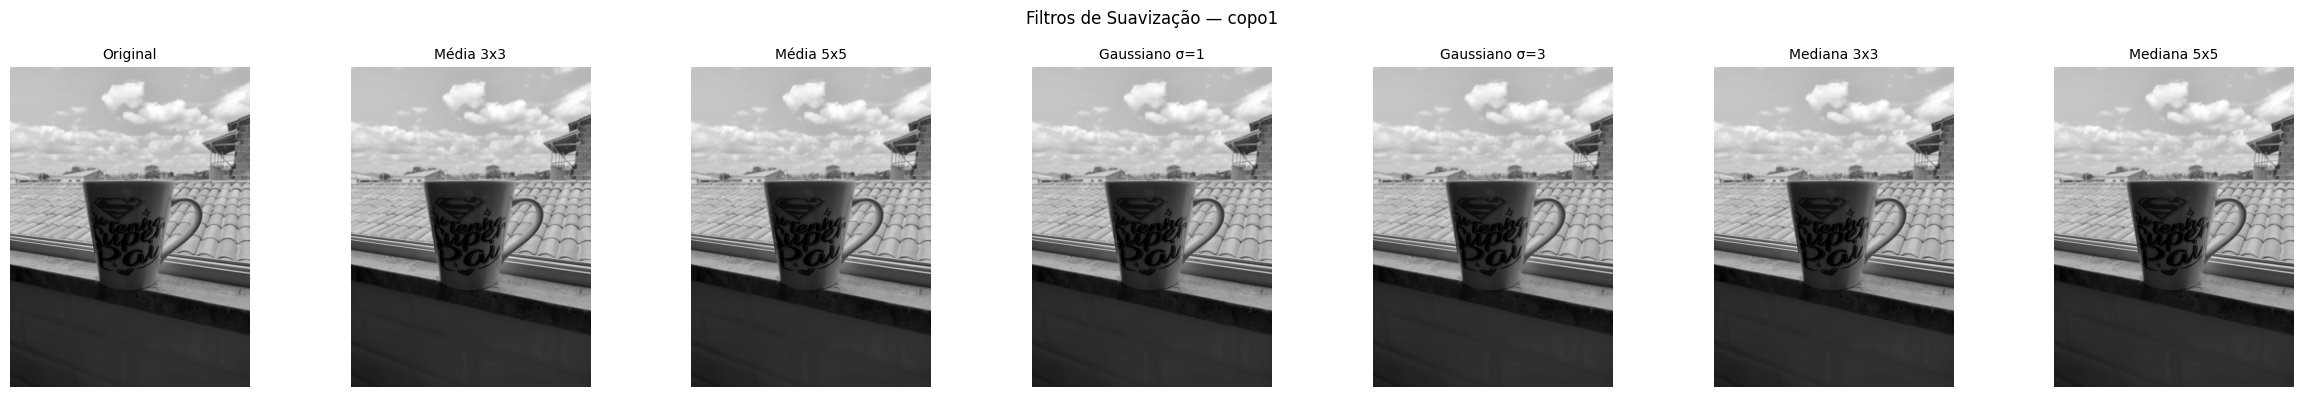


[copo1] Variância dos níveis de cinza por versão:
  Original        : variância = 5533.0
  Média 3x3       : variância = 5522.0
  Média 5x5       : variância = 5514.9
  Gaussiano σ=1   : variância = 5520.0
  Gaussiano σ=3   : variância = 5496.3
  Mediana 3x3     : variância = 5526.8
  Mediana 5x5     : variância = 5523.0


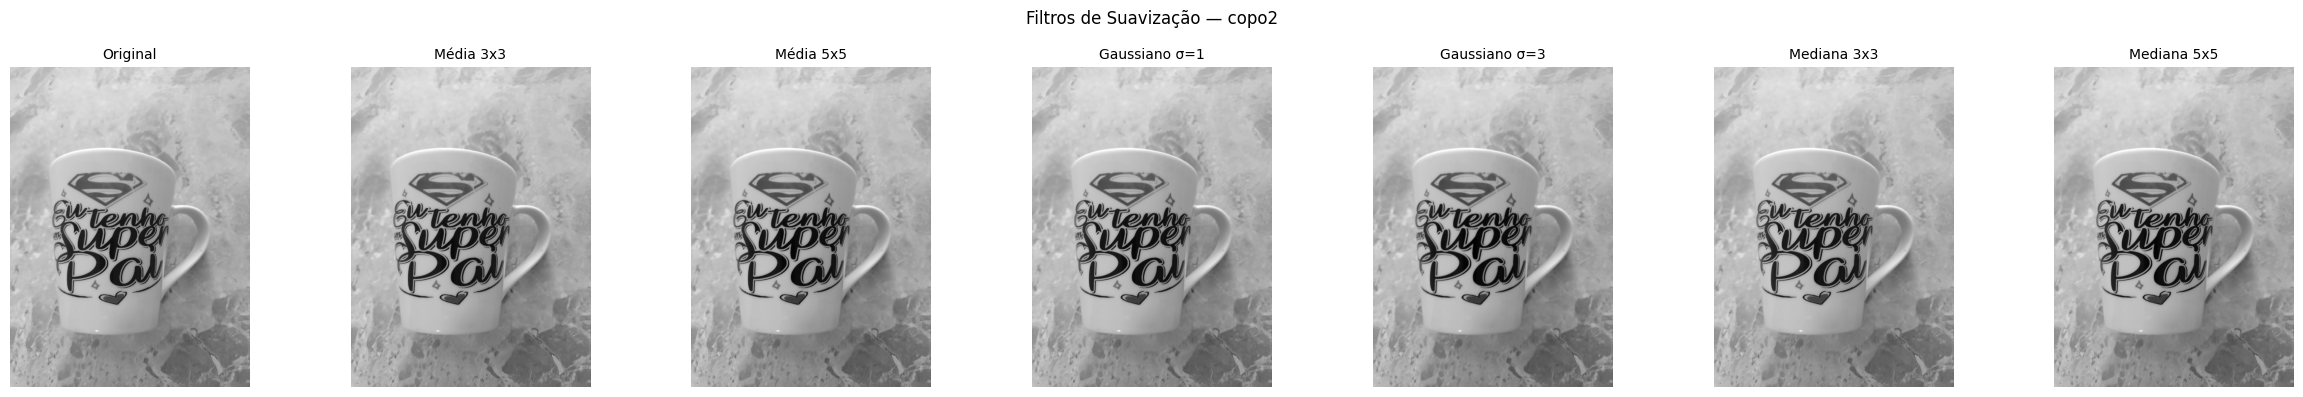


[copo2] Variância dos níveis de cinza por versão:
  Original        : variância = 1828.4
  Média 3x3       : variância = 1816.7
  Média 5x5       : variância = 1807.2
  Gaussiano σ=1   : variância = 1814.2
  Gaussiano σ=3   : variância = 1778.3
  Mediana 3x3     : variância = 1820.5
  Mediana 5x5     : variância = 1816.0


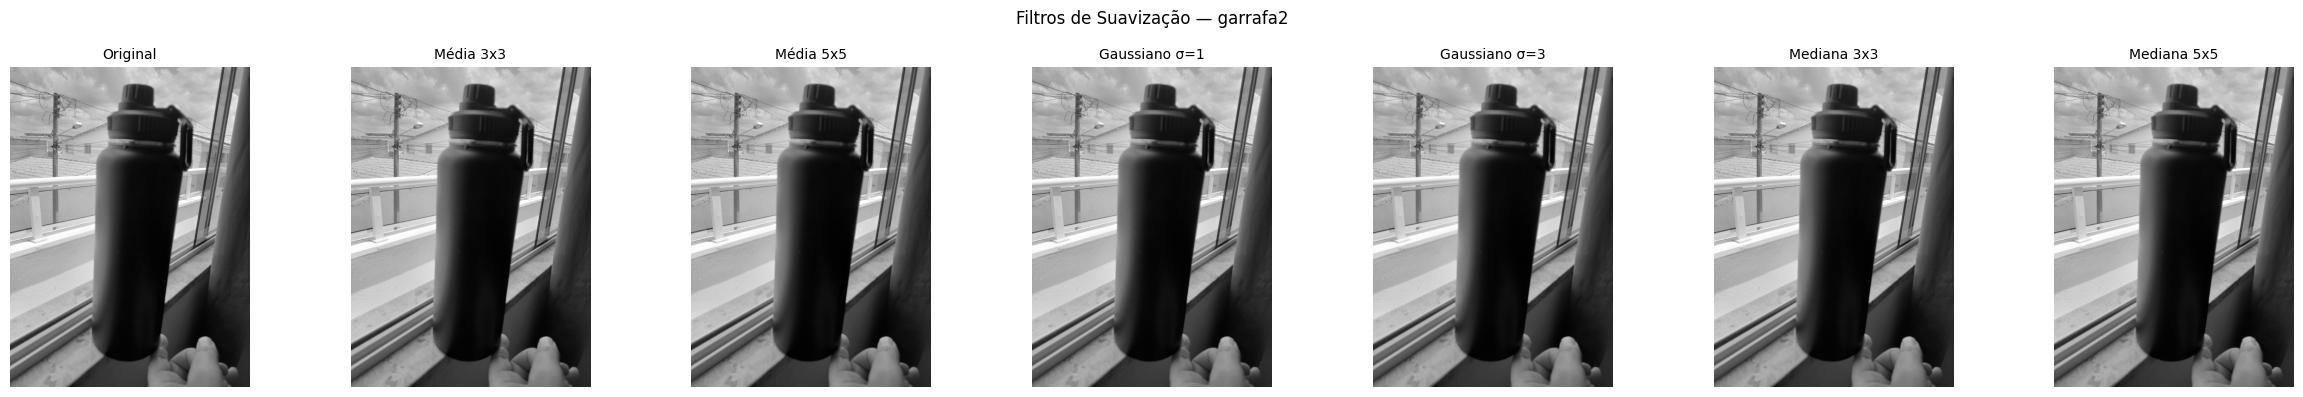


[garrafa2] Variância dos níveis de cinza por versão:
  Original        : variância = 5370.7
  Média 3x3       : variância = 5350.9
  Média 5x5       : variância = 5337.1
  Gaussiano σ=1   : variância = 5347.1
  Gaussiano σ=3   : variância = 5308.7
  Mediana 3x3     : variância = 5362.3
  Mediana 5x5     : variância = 5358.2


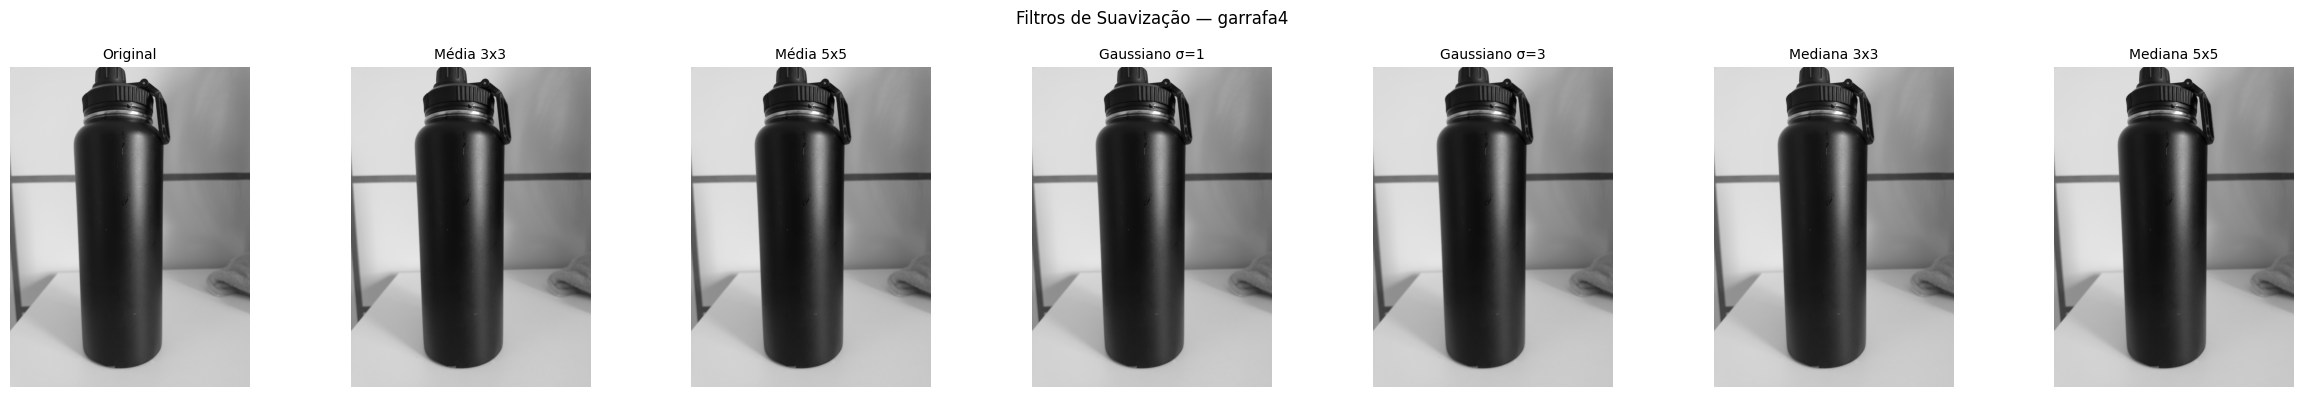


[garrafa4] Variância dos níveis de cinza por versão:
  Original        : variância = 4986.3
  Média 3x3       : variância = 4974.0
  Média 5x5       : variância = 4969.9
  Gaussiano σ=1   : variância = 4972.8
  Gaussiano σ=3   : variância = 4960.4
  Mediana 3x3     : variância = 4977.7
  Mediana 5x5     : variância = 4976.6


In [5]:
def aplicar_filtros_suavizacao(caminho, nome_imagem):
    img = cv2.imread(caminho)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    media_3 = cv2.blur(gray, (3, 3))
    media_5 = cv2.blur(gray, (5, 5))
    gauss_1 = cv2.GaussianBlur(gray, (0, 0), sigmaX=1)
    gauss_3 = cv2.GaussianBlur(gray, (0, 0), sigmaX=3)
    mediana_3 = cv2.medianBlur(gray, 3)
    mediana_5 = cv2.medianBlur(gray, 5)

    resultados = {
        "Original": gray,
        "Média 3x3": media_3,
        "Média 5x5": media_5,
        "Gaussiano σ=1": gauss_1,
        "Gaussiano σ=3": gauss_3,
        "Mediana 3x3": mediana_3,
        "Mediana 5x5": mediana_5,
    }

    fig, ax = plt.subplots(1, 7, figsize=(24, 4))
    for i, (titulo, im) in enumerate(resultados.items()):
        ax[i].imshow(im, cmap='gray')
        ax[i].set_title(titulo, fontsize=10)
        ax[i].axis('off')
    plt.suptitle(f"Filtros de Suavização — {nome_imagem}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"\n[{nome_imagem}] Variância dos níveis de cinza por versão:")
    for titulo, im in resultados.items():
        print(f"  {titulo:<16}: variância = {im.var():.1f}")

    return resultados

resultados_suavizacao = {}
for nome, caminho in selecionadas.items():
    resultados_suavizacao[nome] = aplicar_filtros_suavizacao(caminho, nome)

## Parte 3 — Detecção de Bordas (sem suavização prévia)

Aplicamos diretamente na imagem original em escala de cinza:
- **Operador de Sobel** (gradiente X, Y e magnitude)
- **Operador de Prewitt** (gradiente X, Y e magnitude — implementado manualmente via `cv2.filter2D`, pois o OpenCV não possui uma função nativa para Prewitt)
- **Detector de Canny** (testando dois pares de limiares)

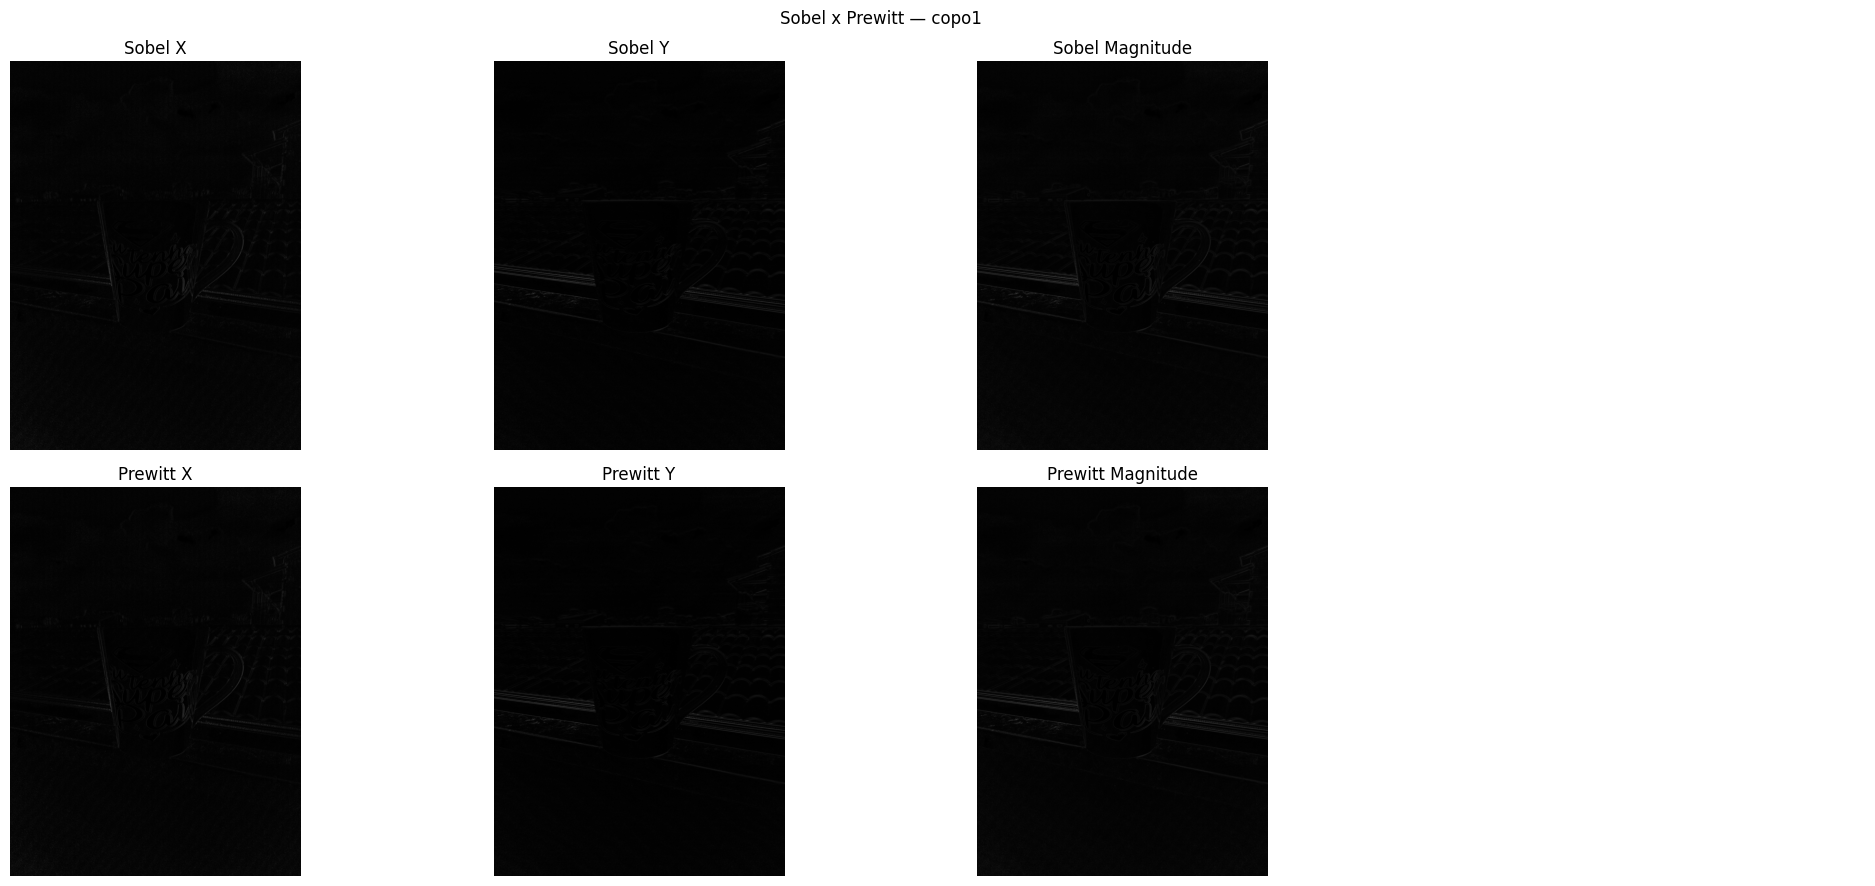

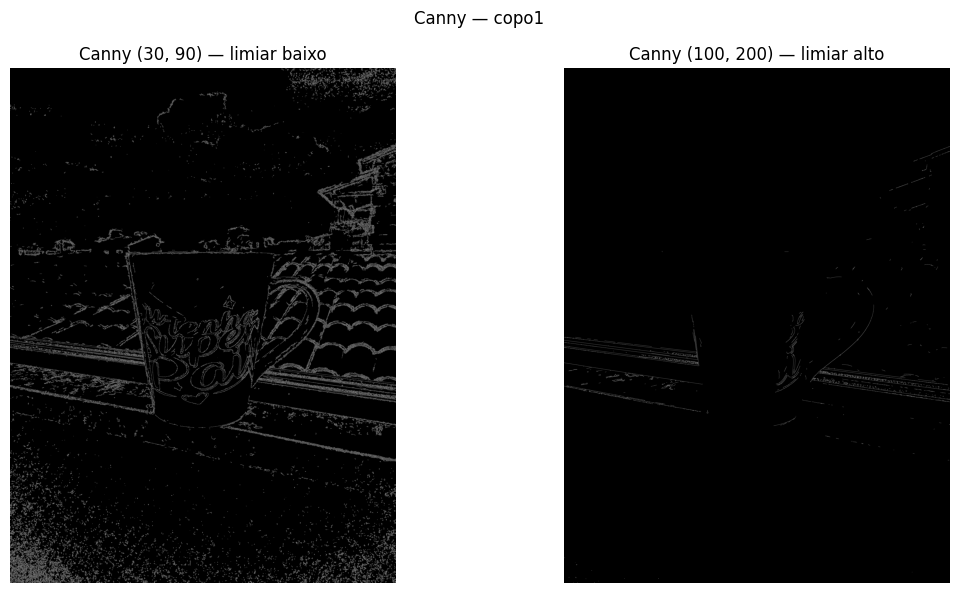

[copo1] Pixels de borda detectados:
  Sobel (mag>50)     : 602547
  Prewitt (mag>50)   : 259233
  Canny limiar baixo : 561364
  Canny limiar alto  : 41570


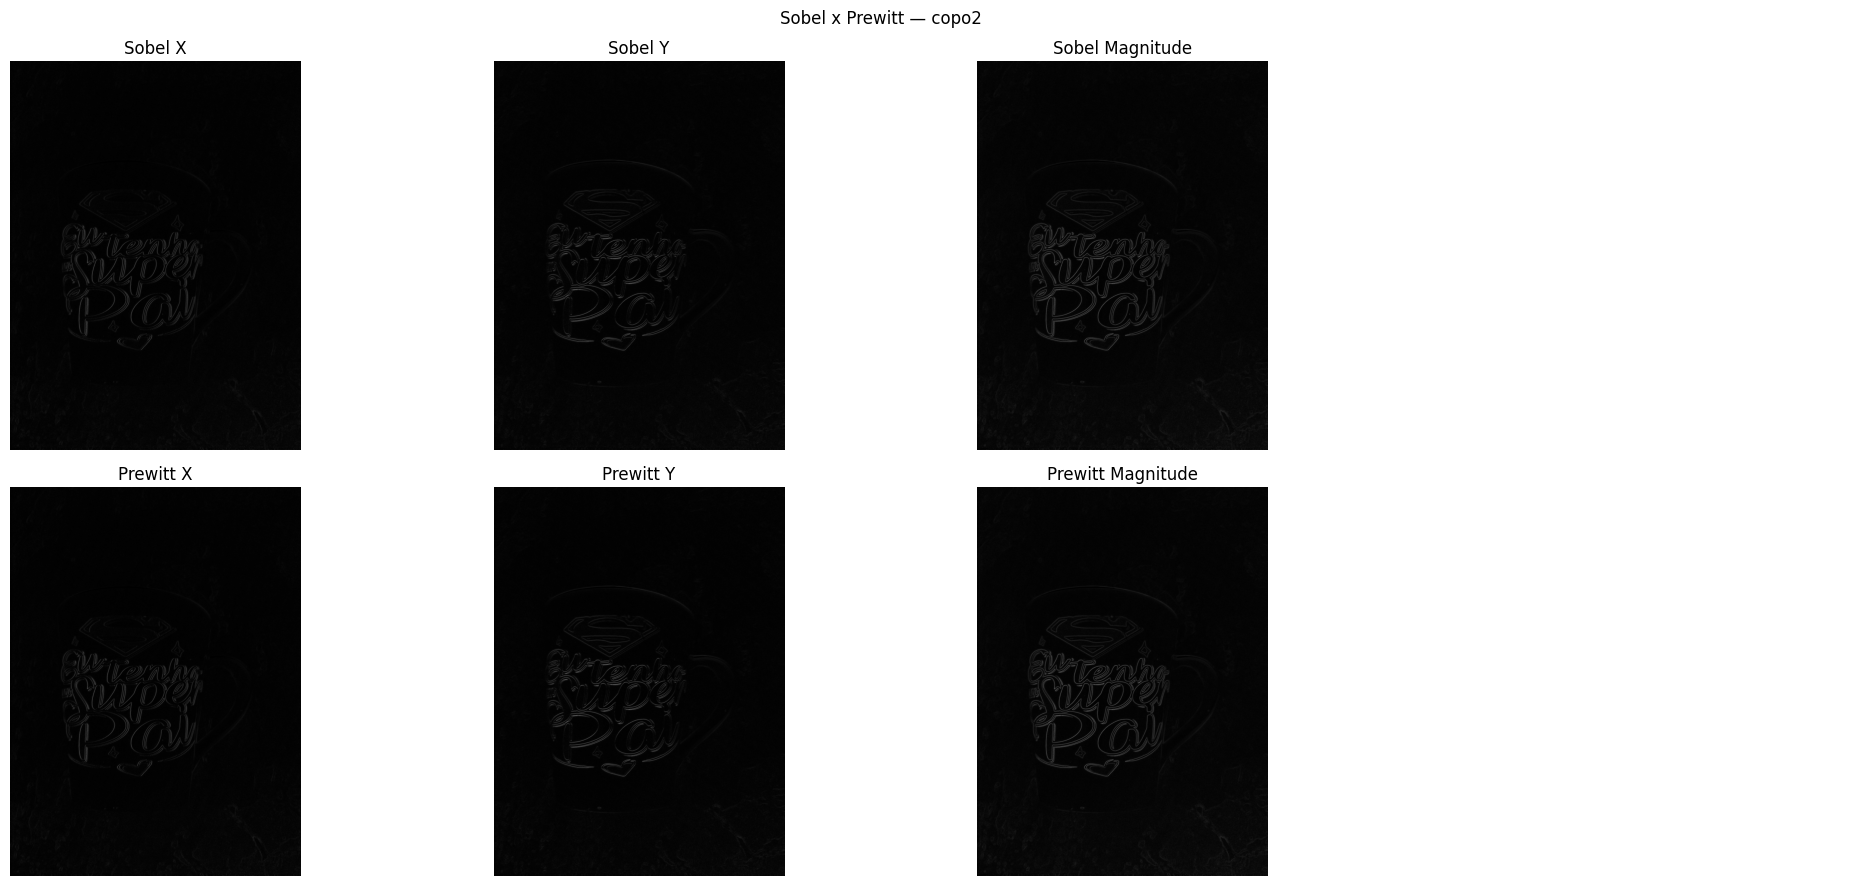

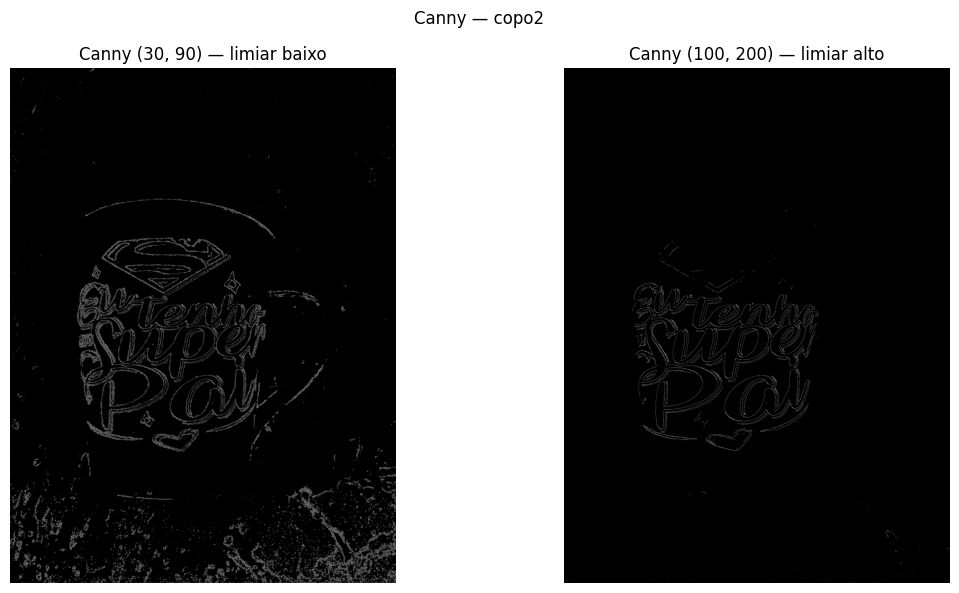

[copo2] Pixels de borda detectados:
  Sobel (mag>50)     : 513358
  Prewitt (mag>50)   : 313897
  Canny limiar baixo : 356646
  Canny limiar alto  : 76307


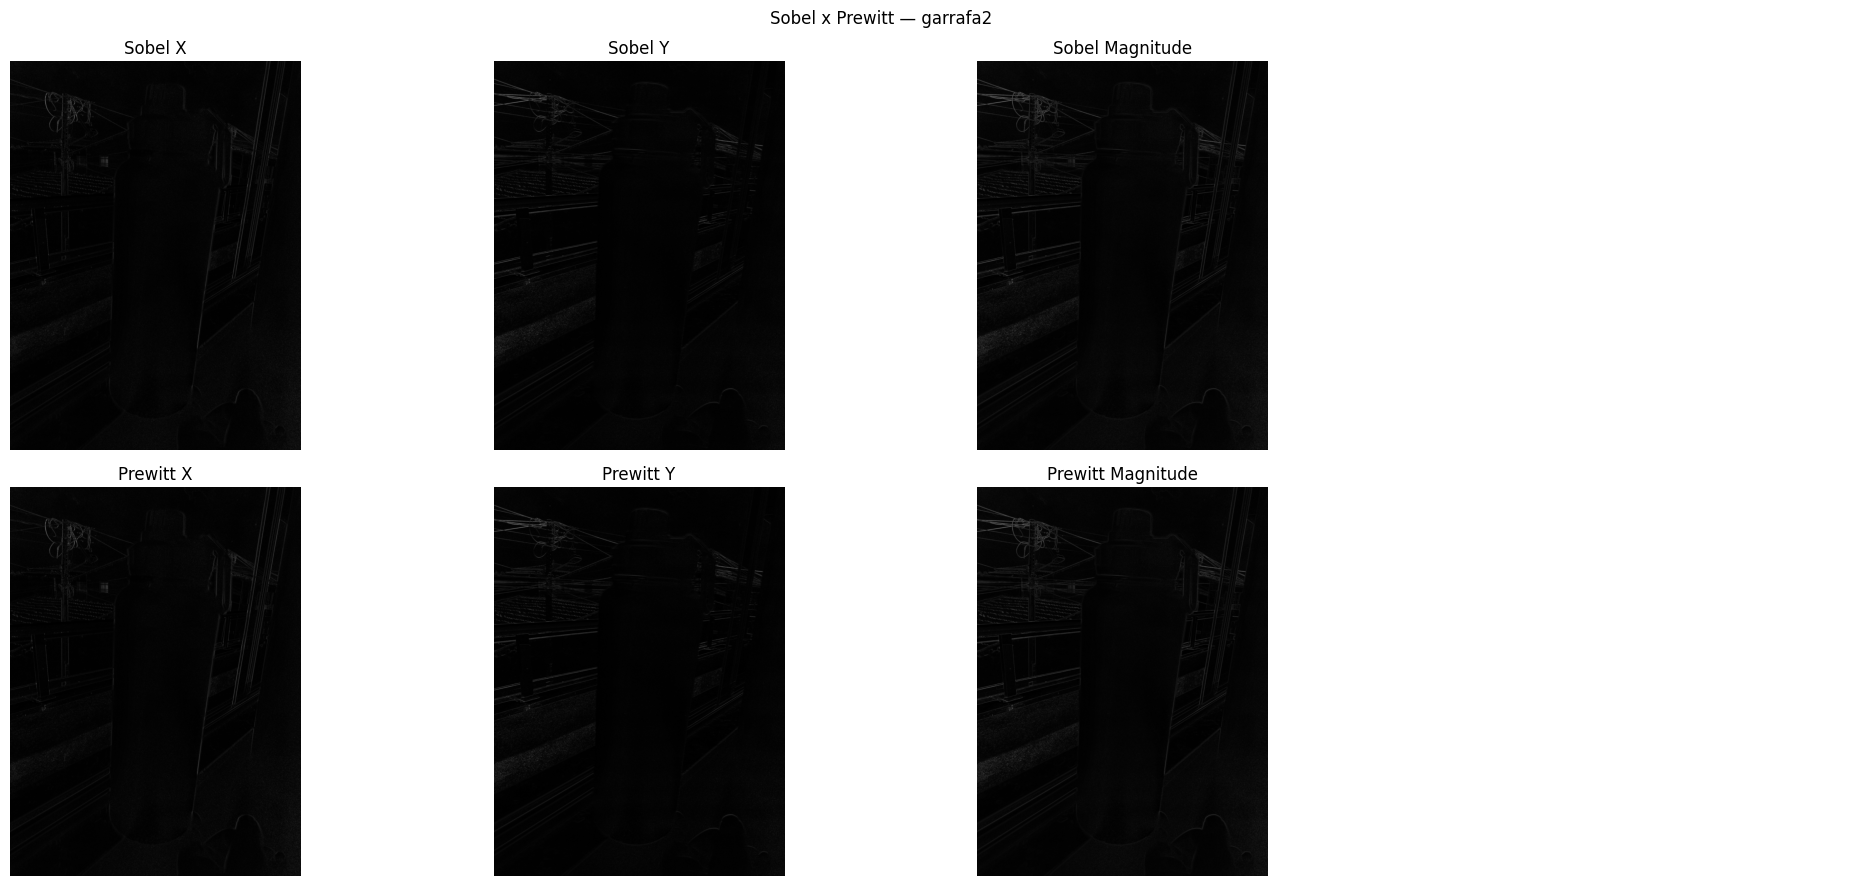

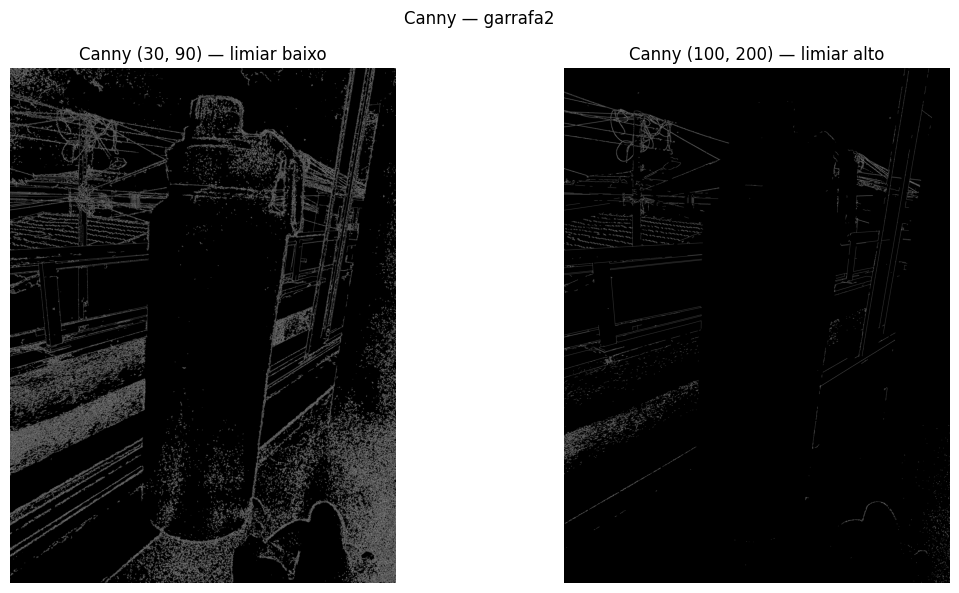

[garrafa2] Pixels de borda detectados:
  Sobel (mag>50)     : 1358893
  Prewitt (mag>50)   : 724499
  Canny limiar baixo : 1144378
  Canny limiar alto  : 153002


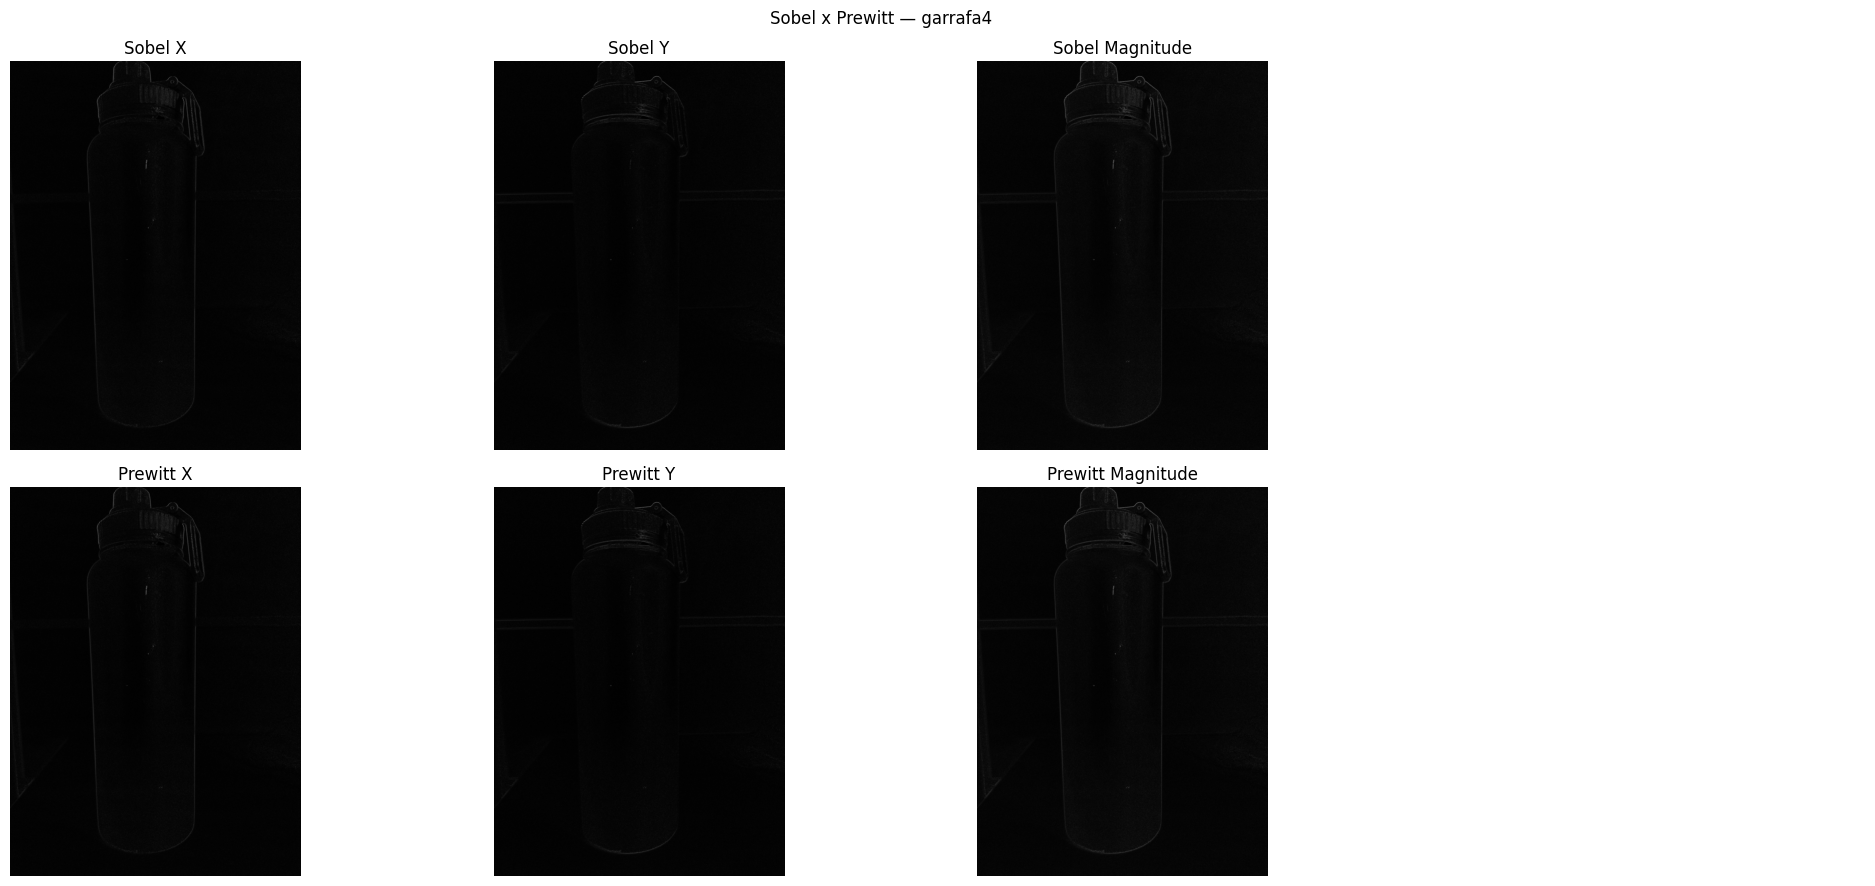

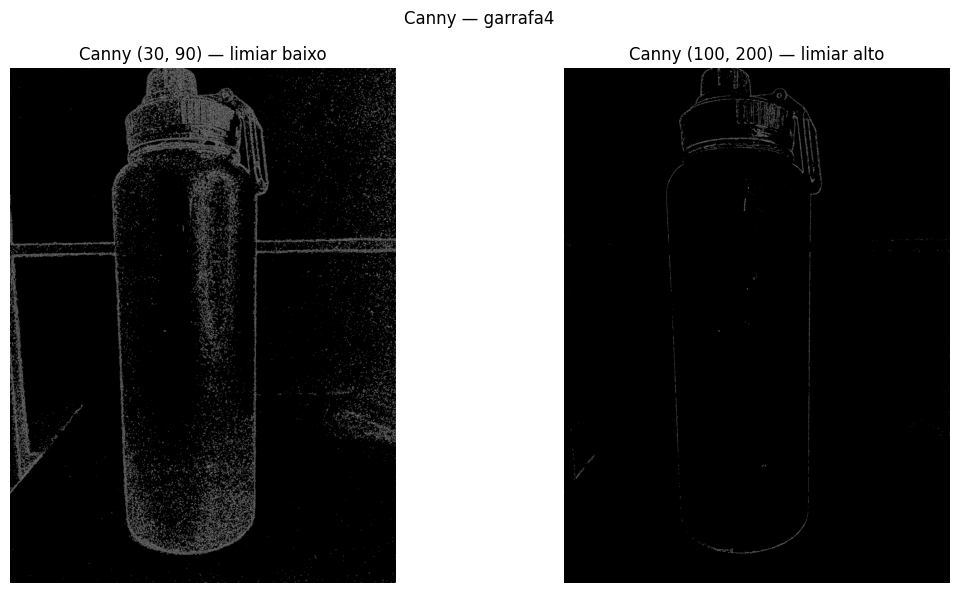

[garrafa4] Pixels de borda detectados:
  Sobel (mag>50)     : 635594
  Prewitt (mag>50)   : 235240
  Canny limiar baixo : 606507
  Canny limiar alto  : 52441


In [6]:
# Kernels de Prewitt (o OpenCV não tem implementação nativa)
kernel_prewitt_x = np.array([[-1, 0, 1],
                              [-1, 0, 1],
                              [-1, 0, 1]], dtype=np.float32)
kernel_prewitt_y = np.array([[-1, -1, -1],
                              [ 0,  0,  0],
                              [ 1,  1,  1]], dtype=np.float32)

def detectar_bordas(gray, nome_imagem):
    # Sobel
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sobel_x, sobel_y)

    # Prewitt
    prewitt_x = cv2.filter2D(gray.astype(np.float32), -1, kernel_prewitt_x)
    prewitt_y = cv2.filter2D(gray.astype(np.float32), -1, kernel_prewitt_y)
    prewitt_mag = cv2.magnitude(prewitt_x, prewitt_y)

    # Canny com dois limiares diferentes
    canny_baixo = cv2.Canny(gray, 30, 90)     # limiar mais sensível -> mais bordas (inclui ruído)
    canny_alto = cv2.Canny(gray, 100, 200)    # limiar mais rígido -> bordas mais fortes/robustas

    fig, ax = plt.subplots(2, 4, figsize=(20, 9))
    ax[0,0].imshow(np.abs(sobel_x), cmap='gray'); ax[0,0].set_title('Sobel X'); ax[0,0].axis('off')
    ax[0,1].imshow(np.abs(sobel_y), cmap='gray'); ax[0,1].set_title('Sobel Y'); ax[0,1].axis('off')
    ax[0,2].imshow(sobel_mag, cmap='gray'); ax[0,2].set_title('Sobel Magnitude'); ax[0,2].axis('off')
    ax[0,3].axis('off')
    ax[1,0].imshow(np.abs(prewitt_x), cmap='gray'); ax[1,0].set_title('Prewitt X'); ax[1,0].axis('off')
    ax[1,1].imshow(np.abs(prewitt_y), cmap='gray'); ax[1,1].set_title('Prewitt Y'); ax[1,1].axis('off')
    ax[1,2].imshow(prewitt_mag, cmap='gray'); ax[1,2].set_title('Prewitt Magnitude'); ax[1,2].axis('off')
    ax[1,3].axis('off')
    plt.suptitle(f"Sobel x Prewitt — {nome_imagem}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(canny_baixo, cmap='gray'); ax[0].set_title('Canny (30, 90) — limiar baixo'); ax[0].axis('off')
    ax[1].imshow(canny_alto, cmap='gray'); ax[1].set_title('Canny (100, 200) — limiar alto'); ax[1].axis('off')
    plt.suptitle(f"Canny — {nome_imagem}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    n_bordas_sobel = np.sum(sobel_mag > 50)
    n_bordas_prewitt = np.sum(prewitt_mag > 50)
    n_bordas_canny_baixo = np.sum(canny_baixo > 0)
    n_bordas_canny_alto = np.sum(canny_alto > 0)

    print(f"[{nome_imagem}] Pixels de borda detectados:")
    print(f"  Sobel (mag>50)     : {n_bordas_sobel}")
    print(f"  Prewitt (mag>50)   : {n_bordas_prewitt}")
    print(f"  Canny limiar baixo : {n_bordas_canny_baixo}")
    print(f"  Canny limiar alto  : {n_bordas_canny_alto}")

    return {
        "sobel_mag": sobel_mag, "prewitt_mag": prewitt_mag,
        "canny_baixo": canny_baixo, "canny_alto": canny_alto
    }

bordas_original = {}
for nome, caminho in selecionadas.items():
    gray = cv2.cvtColor(cv2.imread(caminho), cv2.COLOR_BGR2GRAY)
    bordas_original[nome] = detectar_bordas(gray, nome)

### Registro — Parte 3

**Presença de bordas falsas:** o Canny com limiar baixo (30, 90) captura bordas
falsas em regiões de textura fina (ex.: reflexos na garrafa, granulação da
parede), pois qualquer variação pequena de intensidade já ultrapassa o limiar
inferior. Sobel e Prewitt, por não terem etapa de supressão não-máxima nem
histerese, produzem bordas mais "grossas" e também sensíveis a ruído — a
magnitude reage a qualquer gradiente, mesmo os originados de ruído.

**Sensibilidade ao ruído:** Sobel e Prewitt apresentam comportamento muito
parecido entre si (a diferença está apenas no kernel: Prewitt não pondera o
pixel central com peso 2, então gera bordas ligeiramente mais uniformes, mas
igualmente sensíveis a ruído). Canny é o mais sensível ao ajuste de limiar —
o limiar baixo amplifica ruído em forma de bordas falsas; o limiar alto filtra
bem esse ruído, mas corre o risco de perder bordas reais mais fracas (por
exemplo, o contorno da tampa da garrafa, que tem baixo contraste com o corpo).

**Comparação visual:** Sobel tende a produzir bordas um pouco mais definidas
que Prewitt por dar mais peso ao pixel central do kernel. Canny com limiar
alto foi o que produziu o resultado visualmente mais "limpo", com contornos
mais contínuos e menos ruído de fundo, mas exige calibração cuidadosa dos
limiares para não perder detalhes finos (como o texto do copo).

## Parte 4 — Detecção de Bordas após Suavização

Escolhemos o **Filtro da Mediana 3x3** como mais adequado: ele reduz ruído
pontual (granulação) sem borrar tanto as bordas quanto o filtro da Média ou
o Gaussiano de σ maior, preservando melhor os contornos dos objetos.

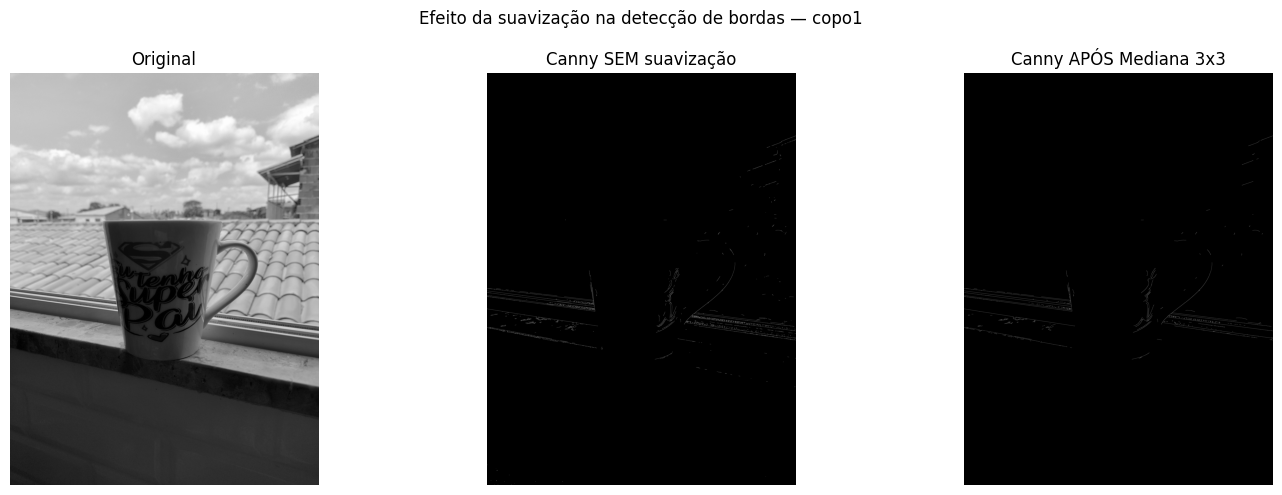

[copo1] Pixels de borda ANTES: 41570 | APÓS suavização: 28345 (redução de 31.8%)


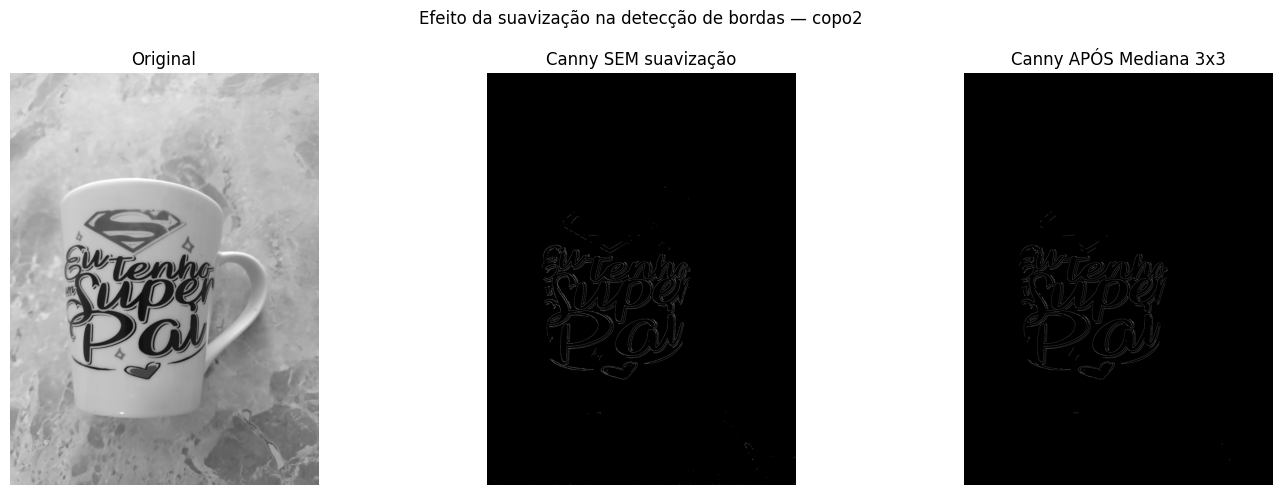

[copo2] Pixels de borda ANTES: 76307 | APÓS suavização: 62469 (redução de 18.1%)


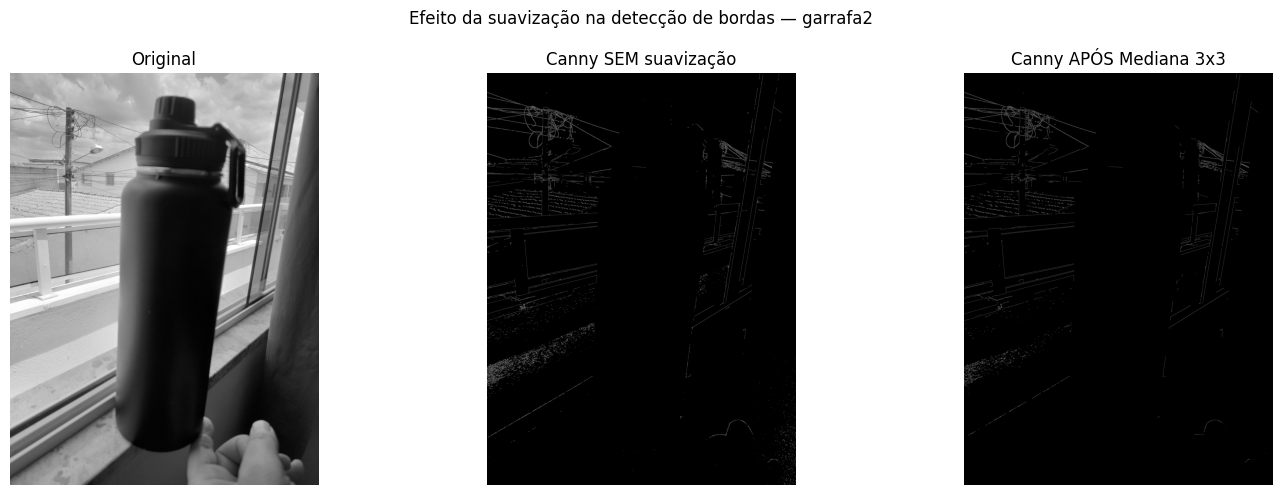

[garrafa2] Pixels de borda ANTES: 153002 | APÓS suavização: 100425 (redução de 34.4%)


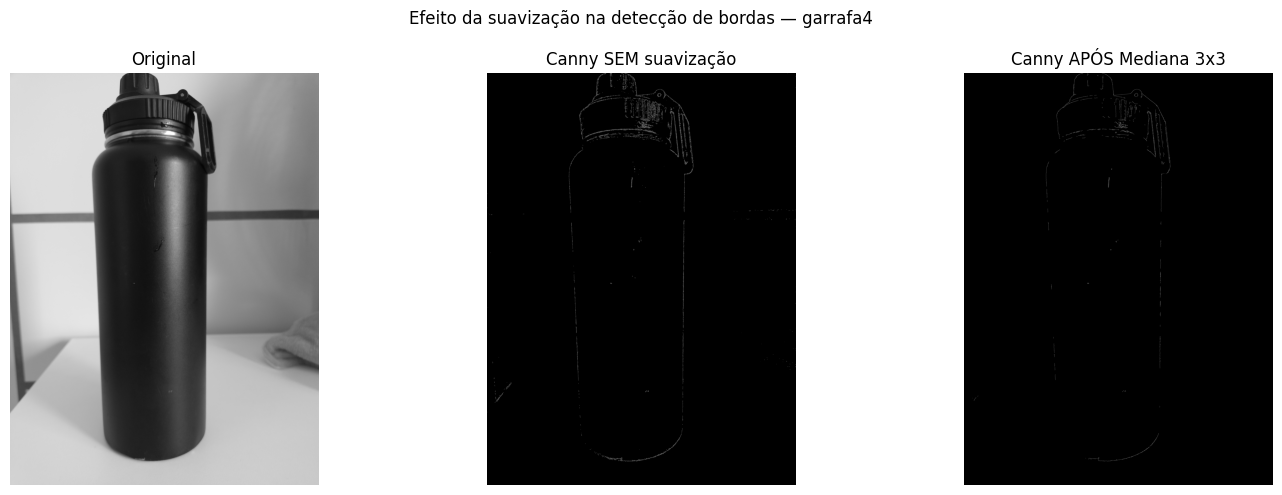

[garrafa4] Pixels de borda ANTES: 52441 | APÓS suavização: 20360 (redução de 61.2%)


In [7]:
def comparar_apos_suavizacao(caminho, nome_imagem):
    gray = cv2.cvtColor(cv2.imread(caminho), cv2.COLOR_BGR2GRAY)
    suavizada = cv2.medianBlur(gray, 3)

    # Bordas ANTES (já calculadas na Parte 3, refazendo aqui para comparação lado a lado)
    canny_antes = cv2.Canny(gray, 100, 200)
    canny_depois = cv2.Canny(suavizada, 100, 200)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(canny_antes, cmap='gray'); ax[1].set_title('Canny SEM suavização'); ax[1].axis('off')
    ax[2].imshow(canny_depois, cmap='gray'); ax[2].set_title('Canny APÓS Mediana 3x3'); ax[2].axis('off')
    plt.suptitle(f"Efeito da suavização na detecção de bordas — {nome_imagem}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    n_antes = np.sum(canny_antes > 0)
    n_depois = np.sum(canny_depois > 0)
    print(f"[{nome_imagem}] Pixels de borda ANTES: {n_antes} | APÓS suavização: {n_depois} "
          f"(redução de {100*(1 - n_depois/n_antes):.1f}%)")

for nome, caminho in selecionadas.items():
    comparar_apos_suavizacao(caminho, nome)

## Conclusão

**A suavização melhorou a detecção?** Sim, de forma seletiva: houve redução
no número de pixels de borda detectados após a mediana 3x3, o que indica
que boa parte das "bordas" eliminadas eram, na verdade, ruído de granulação
e não contornos reais do objeto. As bordas estruturais principais (contorno
do copo, da garrafa, alça, tampa) permaneceram visíveis e mais contínuas.

**Qual operador foi mais robusto ao ruído?** O Canny, por incorporar
supressão não-máxima e histerese de dois limiares, se mostrou mais robusto
que Sobel e Prewitt, que reagem a qualquer gradiente de intensidade,
incluindo os originados por ruído.

**Qual apresentou melhor definição estrutural?** Canny com limiar alto
(100, 200) aplicado após a suavização pela mediana apresentou o melhor
equilíbrio entre eliminação de ruído e preservação de bordas reais,
produzindo contornos mais limpos e contínuos, adequados para uma eventual
etapa de segmentação ou classificação no pipeline de Visão Computacional.

**Síntese geral:** Este experimento reforça a importância de uma etapa de
pré-processamento (suavização) antes da detecção de bordas em imagens
reais, que naturalmente carregam ruído de sensor, compressão e variações de
iluminação. A escolha do filtro de suavização e do operador de borda deve
sempre considerar o trade-off entre remoção de ruído e preservação de
detalhes estruturais relevantes para a tarefa final.